In [1]:
using Sunny, GLMakie # import Sunny and a plotting package GLMakie. 

[ Info: Precompiling GLMakie [e9467ef8-e4e7-5192-8a1a-b1aee30e663a] 
[ Info: Precompiling BrillouinMakieExt [ee195273-3c66-518a-ad00-7cbc5a420344] (cache misses: wrong dep version loaded (2))
[ Info: Precompiling PlottingExt [2e29e6af-0e81-5969-9de0-66bd86bb1753] (cache misses: wrong dep version loaded (2))
[ Info: Precompiling GLMakiePrecompilesExt [e1c8227e-5c94-5199-9fb4-a8dc3842a0b3] (cache misses: wrong dep version loaded (2))


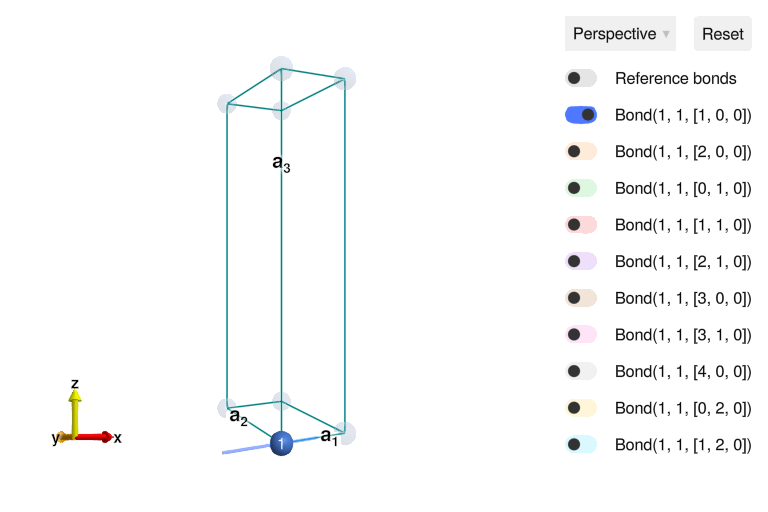

In [2]:
# Set up a cubic crystal with 2 of the axes much longer than the x-axis (which will be our chain direction)
# the length of these other axes are not important, we just want them > a
a = 5 # (Å)
latvecs = lattice_vectors(a, 2a, 5a, 90, 90, 90) 
positions = [[0 0 0]] #put atoms of the vertices of this lattice
cryst = Crystal(latvecs, positions; )
view_crystal(cryst) #we can plot this and view the atoms/bonds

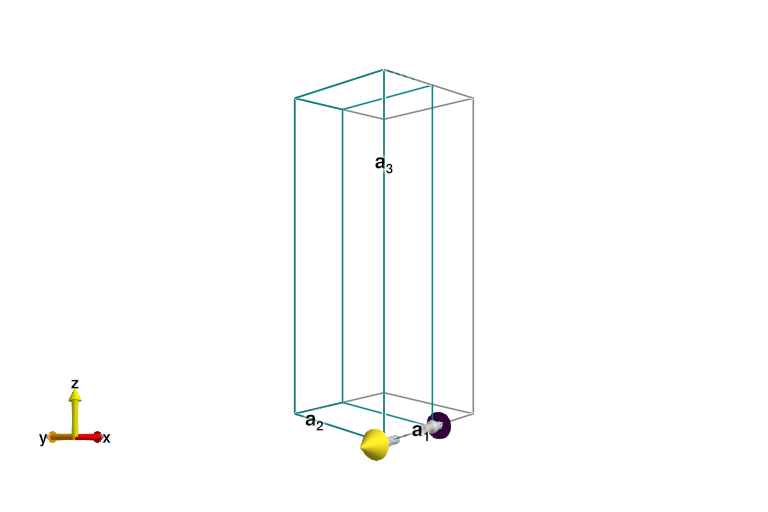

In [3]:
# Now we define a spin system. This means telling the code what spins each atom has
# We need to tell Sunny what crystal to use (the one we created above), the magnetic moment of the atom (here we choose site one to have an 
# S=1) and the mode of calculation, here we choose dipole. 
# Dipole mode is standard LSWT i.e. we consider only a single flavor of Holstein Primakoff boson. This is akin to treating each site as a 2-level system.
# Note that g is the g-factor which is 2 for a spin only magnetic ion.
# We also specify the kwarg "dims" which is the size of the supercell. Since we have an AFM, the supercell should be (2,1,1)
dims = (2,1,1)
sys = System(cryst, [1 => Moment(s=1, g=2)], :dipole;dims)
# Now we assign bonds to this system. The labeling mirrors that of the view_crystal function
J = 1.0 # (>0 => AFM)
set_exchange!(sys, J, Bond(1, 1, [1, 0, 0]))
# we randomize the spins and then perform an energy minimization of the 
randomize_spins!(sys)
minimize_energy!(sys)
plot_spins(sys; color=[S[3] for S in sys.dipoles])

In [4]:
# S^αβ(q,w) is a 3x3 matrix with the elements corresponding to α,β ∈ [x,y,z]. We need to specify how we wish to contract this matrix to plot.
# In conventional neutron scattering they measure the component perpendicular to  the momentum transfer. To specify this we use ssf_perp(sys). 
# The trace is specificed by ssf_trace
measure = ssf_trace(sys; )
swt = SpinWaveTheory(sys; measure) # constructs an object to do LSWT on 

SpinWaveTheory [Dipole mode]
  2 atoms


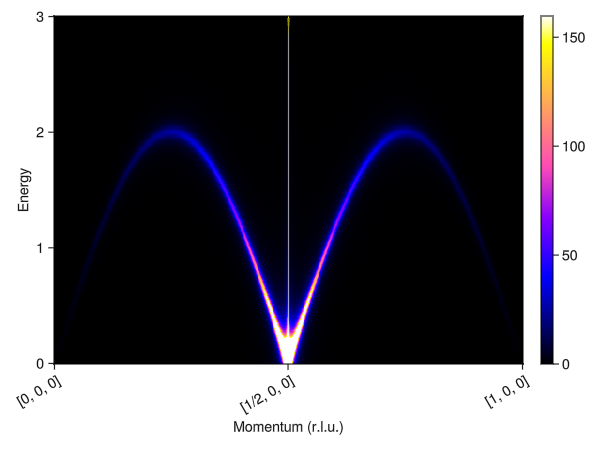

In [5]:
kernel = lorentzian(fwhm=0.1) # chooses a kernel. In the Lehmann Representation of the dynamical susceptibilty we saw a delta function. This here approximates this with a finite width Lorentzian
# Choose some reciprocal space path. Since it is 1-d only 1 direction makes sense.
qs = [[0, 0, 0], [1/2, 0, 0], [1 0 0]]
path = q_space_path(cryst, qs, 500)
energies = range(0, 3, 300) # choose energy range
# calculate ∑ⱼSʲʲ(q,ω) and plot.
res = intensities(swt, path; energies, kernel)
plot_intensities(res;)

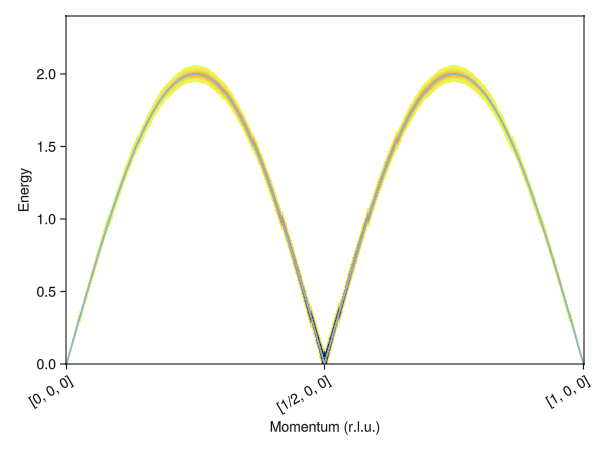

In [6]:
# Perhaps more useful would be to plot the bands rather than a colormap. For this we can do:
res = intensities_bands(swt, path)
plot_intensities(res; )